# <font color="blue">**Galaxies and Nebulae**</font>

<img src="https://raw.githubusercontent.com/deltorobarba/science/main/nature.JPG" alt="science">


<font color="blue">*Pipeline: from a galaxy catalogue to multi-wavelength images and a measured light profile*</font>

Choose a bright galaxy from a catalogue, pull its properties and published distances, download images of it in six wavebands, and fit its radial light profile. The structure follows the exoplanet section: catalogue → selection → raw data → own measurement → comparison with the catalogue.

| Cell | What it does | Database |
|---|---|---|
| Setup | Installs `astroquery` (keeps NumPy < 2 in a local Anaconda kernel) and imports | – |
| 1. Load Catalogue Data | Brightest galaxies on the sky (V < 10.5, major axis ≥ 3′), overview of object types, Top-K table | SIMBAD (CDS Strasbourg, TAP/ADQL) |
| 2. Select galaxy | `SELECTED_GALAXY = "M 51"`: Hubble type, magnitudes, recession velocity, distance (median of the redshift-independent measurements), physical diameter in kpc, absolute magnitude. Plot of the published distances by method, compared with the Hubble law | SIMBAD, **NASA/IPAC NED** |
| 3. Multi-wavelength images | Six images of the same galaxy: GALEX near-UV, DSS2 blue and red, 2MASS K, WISE 3.4 µm and 12 µm, with the catalogue ellipse overlaid | **NASA SkyView** |
| 4. Colour images | Left: true-colour optical image (DSS2). Right: false colour with red = warm dust (WISE 12 µm), green = old stars (WISE 3.4 µm), blue = young stars (GALEX near-UV) | CDS hips2fits, NASA SkyView |
| 5. Sérsic fit | Radial surface-brightness profile in elliptical annuli (WISE 3.4 µm) and Sérsic fit. The Sérsic index $n$ is compared with the catalogue Hubble type; also half-light radius, disk scale length in kpc and inclination | – |

**Own measurement vs. catalogue.** Step 5 plays the role of the period recovery for the exoplanet: measure something from the raw images and check it against the catalogue. The Sérsic law is $I(r) = I_e \exp\{-b_n[(r/r_e)^{1/n} - 1]\}$, with $n \approx 1$ for an exponential disk (spirals) and $n \approx 4$ for a de Vaucouleurs profile (ellipticals). Rule-of-thumb classification: $n < 2$ disk-dominated, $2 \le n < 2.5$ intermediate, $n \ge 2.5$ spheroid-dominated.

Example results:

* **M 51:** $n = 0.88$, disk-dominated; half-light radius 3.9 kpc, disk scale length $h \approx 2.3$ kpc.
* **M 104 (Sombrero):** $n = 3.1$, bulge-dominated; the dust ring stands out in red in the false-colour image.
* **M 87:** $n = 2.95$. This is lower than published values, because the catalogue size underestimates the extended halo of the elliptical, so the fit range does not reach far enough out. It is still classified as spheroid-dominated.

Notes:

* **Runtime:** the image download takes 20–60 s; SkyView is sometimes slow.
* **Very large galaxies** (M 31, LMC, SMC): the field spans several degrees, and the SkyView mosaics for 2MASS and DSS2 show stripes and plate edges. WISE and GALEX look fine.
* **Nebulae:** the catalogue query returns galaxies only. For nebulae, replace `d.path LIKE 'G%'` in step 1 by `d.path LIKE 'ISM%'` (HII regions, supernova remnants, reflection nebulae) or by `b.otype = 'PN'` (planetary nebulae). Many nebulae have no V magnitude in SIMBAD, so loosen the V cut. Steps 3 and 4 work unchanged; step 5 and the distance comparison only make sense for galaxies.

In [ ]:
import sys
NUMPY_PIN = "" if "google.colab" in sys.modules else "'numpy<2'"   # local Anaconda is built on NumPy 1.x (pyarrow, numba)
%pip install -q astroquery {NUMPY_PIN}
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.optimize import curve_fit
from scipy.special import gammaincinv

from astropy import units as u
from astropy.coordinates import SkyCoord, Angle
from astroquery.simbad import Simbad
from astroquery.ipac.ned import Ned
from astroquery.skyview import SkyView
from astroquery.hips2fits import hips2fits

plt.rcParams["figure.figsize"] = (9, 4)
pd.set_option("display.max_columns", None)

Note: you may need to restart the kernel to use updated packages.


In [2]:
# 1. Load Catalogue Data from SIMBAD (CDS Strasbourg, TAP/ADQL)
# Goal: Multi-wavelength images and light profile of bright galaxies (NASA SkyView, NED)
MAX_VMAG  = 10.5   # Only galaxies brighter than this V magnitude
MIN_SIZE  = 3.0    # Minimum major axis [arcmin], removes compact objects with doubtful photometry

query = f"""
SELECT b.main_id, b.otype, d.label AS otype_label, b.morph_type, b.ra, b.dec,
       b.rvz_redshift, b.rvz_radvel, b.galdim_majaxis, b.galdim_minaxis, b.galdim_angle,
       f.B AS bmag, f.V AS vmag, f.K AS kmag
FROM basic AS b
JOIN allfluxes AS f ON f.oidref = b.oid
JOIN otypedef AS d ON d.otype = b.otype
WHERE d.path LIKE 'G%' AND b.otype NOT IN ('GrG', 'CGG', 'ClG', 'SCG', 'PCG')   -- no groups / clusters
  AND f.V < {MAX_VMAG} AND b.galdim_majaxis >= {MIN_SIZE}
ORDER BY vmag
"""
catalog_raw = Simbad.query_tap(query)
print(f" ✅ {len(catalog_raw)} galaxies with V < {MAX_VMAG} and size >= {MIN_SIZE}' in SIMBAD")

galaxies_df = catalog_raw.to_pandas()
galaxies_df["main_id"] = galaxies_df["main_id"].str.replace(r"\s+", " ", regex=True)   # "M  51" -> "M 51"
galaxies_df["b_v"] = galaxies_df["bmag"] - galaxies_df["vmag"]                           # colour index
galaxies_df = galaxies_df.drop_duplicates(subset="main_id").reset_index(drop=True)
display(galaxies_df.head())

# Get overview of object types (AGN, Seyfert, Starburst, ...) and Hubble types
print("\n ✅ Object types in the catalog")
display(galaxies_df["otype_label"].value_counts().head(8))

print("\n ✅ Top-K brightest galaxies")
K = 15
top_k = galaxies_df.head(K)
top_k[["main_id", "otype_label", "morph_type", "vmag", "b_v", "galdim_majaxis", "rvz_redshift"]]

 ✅ 129 galaxies with V < 10.5 and size >= 3.0' in SIMBAD


,main_id,otype,otype_label,morph_type,ra,dec,rvz_redshift,rvz_radvel,galdim_majaxis,galdim_minaxis,galdim_angle,bmag,vmag,kmag,b_v
0,NAME LMC,G,Galaxy,SB(s)m,80.894167,-69.756111,0.000875,262.200000,322.826660,274.769989,170,NaN,0.40,NaN,NaN
1,NAME SMC,G,Galaxy,dIrr,13.158333,-72.800278,0.000486,145.600000,158.113327,93.105003,45,2.79,2.20,NaN,0.59
2,M 31,AGN,AGN,SA(s)b,10.684708,41.268750,-0.001000,-300.000000,199.529999,70.790001,35,4.36,3.44,0.984,0.92
3,M 33,GiG,GtowardsGroup,SA(s)cd,23.462069,30.660175,-0.000598,-179.200000,60.259998,35.480000,22,6.27,5.72,4.102,0.55
4,NAME Centaurus A,BLL,BLLac,S0pec,201.365063,-43.019113,0.001877,562.167379,25.700001,17.780001,33,8.18,6.84,3.942,1.34



 ✅ Object types in the catalog


otype_label
GtowardsGroup    23
Seyfert2         21
LINER            16
GinPair          11
EmissionG        10
AGN               8
Galaxy            7
RadioG            6
Name: count, dtype: int64


 ✅ Top-K brightest galaxies


,main_id,otype_label,morph_type,vmag,b_v,galdim_majaxis,rvz_redshift
0,NAME LMC,Galaxy,SB(s)m,0.40,NaN,322.826660,0.000875
1,NAME SMC,Galaxy,dIrr,2.20,0.590000,158.113327,0.000486
2,M 31,AGN,SA(s)b,3.44,0.920000,199.529999,-0.001000
3,M 33,GtowardsGroup,SA(s)cd,5.72,0.550000,60.259998,-0.000598
4,NAME Centaurus A,BLLac,S0pec,6.84,1.340000,25.700001,0.001877
5,M 81,Seyfert2,SA,6.94,0.950000,21.379999,-0.000157
6,MCG-06-07-001,Galaxy,dSph,7.40,1.620000,27.500000,0.000182
7,M 83,StarburstG,SAB(s)c,7.52,0.590000,13.800000,0.001733
8,M 101,GinPair,S_AB,7.86,0.600000,21.879999,0.000811
9,NGC 55,RadioG,Irr,7.87,0.710000,32.360001,0.000430


✅ Galaxy:            M 51   (NED: MESSIER 051, type GPair)
Object type:          Seyfert2   |   Hubble type: SA
Coordinates:          13h29m52.7s +47d11m42.9s
Magnitude:            V = 8.36   B-V = 0.90   K = 5.50
Apparent size:        9.0' x 7.8'   (PA 28 deg)
Recession velocity:   600 km/s   (z = 0.00174)
Distance:             7.85 Mpc = 25.6 million light-years  (median of 6 redshift-independent measurements)
Physical diameter:    20.7 kpc = 67,355 light-years   <- we measure the light profile later
Absolute magnitude:   M_V = -21.11

✅ Hubble-law distance v/H0 = 8.57 Mpc  vs. distance ladder 7.85 Mpc
  Peculiar velocity:  +50 km/s  (local motions dominate below ~20 Mpc)


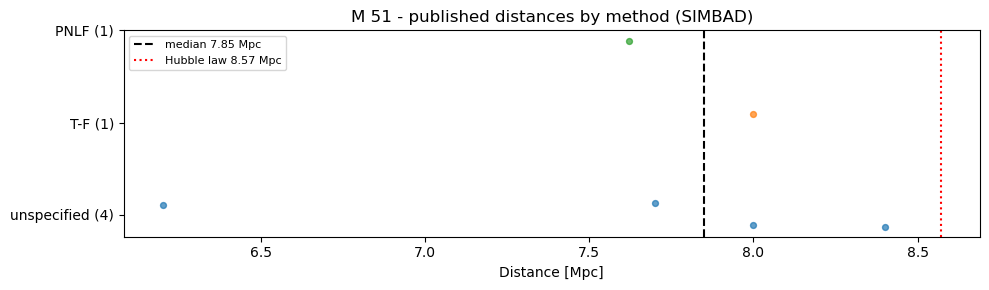

In [3]:
# 2. Select galaxy, get details (SIMBAD + NASA/IPAC Extragalactic Database) and distance
SELECTED_GALAXY = "M 51"   # <- Enter a name from the table above (e.g. "M 31", "M 81", "M 87", "NAME Centaurus A")
H0 = 70.0                  # Hubble constant [km/s/Mpc]

match = galaxies_df.loc[galaxies_df["main_id"] == SELECTED_GALAXY]
if len(match) == 0:
    raise ValueError(f"'{SELECTED_GALAXY}' not found. Check the spelling (note the space in 'M 51').")
info = match.iloc[0]
coord = SkyCoord(info["ra"], info["dec"], unit="deg")
a_arcmin = info["galdim_majaxis"]                                          # catalog major axis [arcmin]
b_arcmin = info["galdim_minaxis"] if pd.notna(info["galdim_minaxis"]) else a_arcmin
pa_deg   = float(info["galdim_angle"]) if pd.notna(info["galdim_angle"]) else 0.0   # north -> east

# Redshift-independent distances (Cepheids, TRGB, PNLF, Tully-Fisher, ...) from SIMBAD
dist_df = Simbad.query_tap(f"""
SELECT m.dist, m.unit, m.method, m.bibcode
FROM mesDistance AS m JOIN ident AS i ON i.oidref = m.oidref
WHERE i.id = '{SELECTED_GALAXY}'
""").to_pandas()
to_mpc = {"Mpc": 1.0, "kpc": 1e-3, "pc": 1e-6}
dist_df["dist_mpc"] = dist_df["dist"] * dist_df["unit"].str.strip().map(to_mpc)
dist_df = dist_df[dist_df["method"].str.strip() != "redshift"].dropna(subset=["dist_mpc"])
dist_mpc = dist_df["dist_mpc"].median()

# Recession velocity from NED (NASA/IPAC)
try:
    ned = Ned.query_object(SELECTED_GALAXY).to_pandas().iloc[0]
    v_rec = float(ned["Velocity"])
except Exception as e:
    ned, v_rec = None, info["rvz_radvel"]
    print(f"⚠️ NED query failed ({e}), using SIMBAD velocity")

kpc_per_arcmin = dist_mpc * 1e3 * np.deg2rad(1 / 60)
size_kpc = a_arcmin * kpc_per_arcmin

print(f"✅ Galaxy:            {SELECTED_GALAXY}" + (f"   (NED: {ned['Object Name']}, type {ned['Type']})" if ned is not None else ""))
print(f"Object type:          {info['otype_label']}   |   Hubble type: {info['morph_type']}")
print(f"Coordinates:          {coord.to_string('hmsdms', precision=1)}")
print(f"Magnitude:            V = {info['vmag']:.2f}   B-V = {info['b_v']:.2f}   K = {info['kmag']:.2f}")
print(f"Apparent size:        {a_arcmin:.1f}' x {b_arcmin:.1f}'   (PA {pa_deg:.0f} deg)")
print(f"Recession velocity:   {v_rec:.0f} km/s   (z = {info['rvz_redshift']:.5f})")
print(f"Distance:             {dist_mpc:.2f} Mpc = {dist_mpc * 3.26156:.1f} million light-years  "
      f"(median of {len(dist_df)} redshift-independent measurements)")
print(f"Physical diameter:    {size_kpc:.1f} kpc = {size_kpc * 3261.56:,.0f} light-years   <- we measure the light profile later")
print(f"Absolute magnitude:   M_V = {info['vmag'] - 5 * np.log10(dist_mpc * 1e5):.2f}")

# Hubble law vs. distance ladder
d_hubble = v_rec / H0
print(f"\n✅ Hubble-law distance v/H0 = {d_hubble:.2f} Mpc  vs. distance ladder {dist_mpc:.2f} Mpc")
print(f"  Peculiar velocity:  {v_rec - H0 * dist_mpc:+.0f} km/s  (local motions dominate below ~20 Mpc)")
if v_rec < 0:
    print("  Blueshift: the galaxy moves towards us (bound to the Local Group, no Hubble flow)")

if len(dist_df):
    methods = dist_df["method"].str.strip().str.upper().replace("", "unspecified")
    order = methods.value_counts().index
    fig, ax = plt.subplots(figsize=(10, 0.5 * len(order) + 1.5))
    for j, m in enumerate(order):
        d = dist_df.loc[methods == m, "dist_mpc"]
        ax.scatter(d, j + np.random.uniform(-0.15, 0.15, len(d)), s=18, alpha=0.7)
    ax.axvline(dist_mpc, color="black", ls="--", label=f"median {dist_mpc:.2f} Mpc")
    if d_hubble > 0:
        ax.axvline(d_hubble, color="red", ls=":", label=f"Hubble law {d_hubble:.2f} Mpc")
    ax.set_yticks(range(len(order)), [f"{m} ({(methods == m).sum()})" for m in order])
    ax.set_xlabel("Distance [Mpc]")
    ax.set_title(f"{SELECTED_GALAXY} - published distances by method (SIMBAD)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

✅ Downloading 6 images, 400x400 px, field 14.5 arcmin (20-60 s)...
   GALEX Near UV   (400, 400)  ok
   DSS2 Blue       (400, 400)  ok
   DSS2 Red        (400, 400)  ok
   2MASS-K         (400, 400)  ok
   WISE 3.4        (400, 400)  ok
   WISE 12         (400, 400)  ok


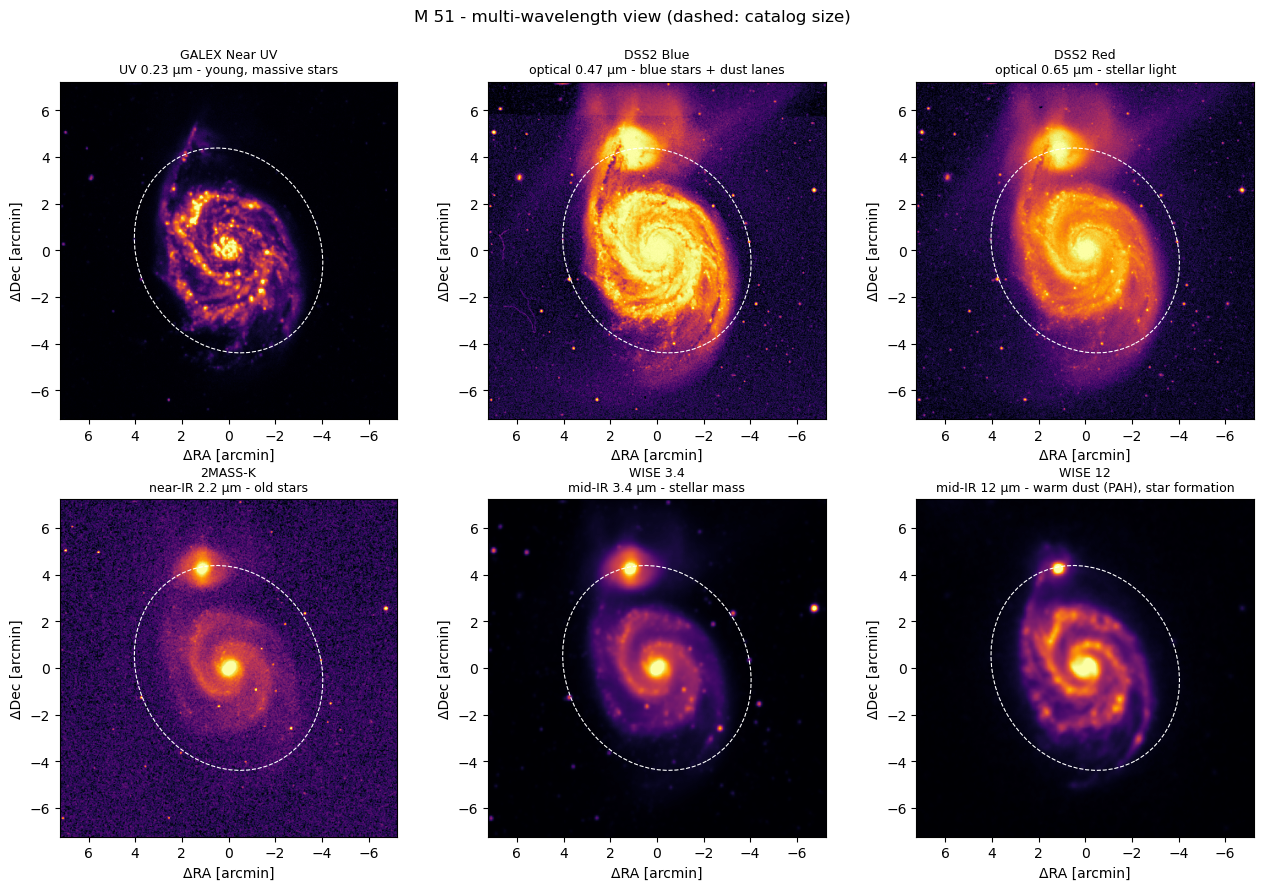

In [4]:
# 3. Load and Visualize Multi-Wavelength Images from NASA SkyView (Goddard Space Flight Center)
# Each band traces a different stellar population / component of the galaxy
SURVEYS = {
    "GALEX Near UV": "UV 0.23 µm - young, massive stars",
    "DSS2 Blue":     "optical 0.47 µm - blue stars + dust lanes",
    "DSS2 Red":      "optical 0.65 µm - stellar light",
    "2MASS-K":       "near-IR 2.2 µm - old stars",
    "WISE 3.4":      "mid-IR 3.4 µm - stellar mass",
    "WISE 12":       "mid-IR 12 µm - warm dust (PAH), star formation",
}
FOV_FACTOR = 1.6    # field of view = FOV_FACTOR x major axis
PIXELS     = 400

fov = FOV_FACTOR * a_arcmin * u.arcmin
print(f"✅ Downloading {len(SURVEYS)} images, {PIXELS}x{PIXELS} px, field {fov:.1f} (20-60 s)...")
hdus = SkyView.get_images(position=coord, survey=list(SURVEYS), pixels=PIXELS,
                          width=fov, height=fov)
images = {}
for name, hdul in zip(SURVEYS, hdus):
    data = hdul[0].data.astype(float)
    if np.nanmax(data) == np.nanmin(data):
        print(f"   {name:15s} no coverage")
        continue
    images[name] = data
    print(f"   {name:15s} {data.shape}  ok")

pix_arcmin = abs(hdus[0][0].header["CDELT1"]) * 60                     # arcmin per pixel
half = PIXELS / 2 * pix_arcmin
extent = [half, -half, -half, half]                                     # east left, north up

def stretch(img, lo=1, hi=99.8):
    """Asinh stretch between percentiles (like ds9 / Aladin)."""
    vmin, vmax = np.nanpercentile(img, [lo, hi])
    x = np.clip((img - vmin) / (vmax - vmin), 0, 1)
    return np.arcsinh(10 * x) / np.arcsinh(10)

def catalog_ellipse(color="white"):
    return Ellipse((0, 0), width=b_arcmin, height=a_arcmin, angle=-pa_deg,
                   fill=False, ec=color, ls="--", lw=0.8)

ncol = 3
nrow = int(np.ceil(len(images) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 4.4 * nrow))
for ax, (name, img) in zip(axes.flat, images.items()):
    ax.imshow(stretch(img), origin="lower", cmap="inferno", extent=extent)
    ax.add_patch(catalog_ellipse())
    ax.set_title(f"{name}\n{SURVEYS[name]}", fontsize=9)
    ax.set_xlabel("ΔRA [arcmin]")
    ax.set_ylabel("ΔDec [arcmin]")
for ax in list(axes.flat)[len(images):]:
    ax.axis("off")
fig.suptitle(f"{SELECTED_GALAXY} - multi-wavelength view (dashed: catalog size)", y=1.0)
fig.tight_layout()
plt.show()

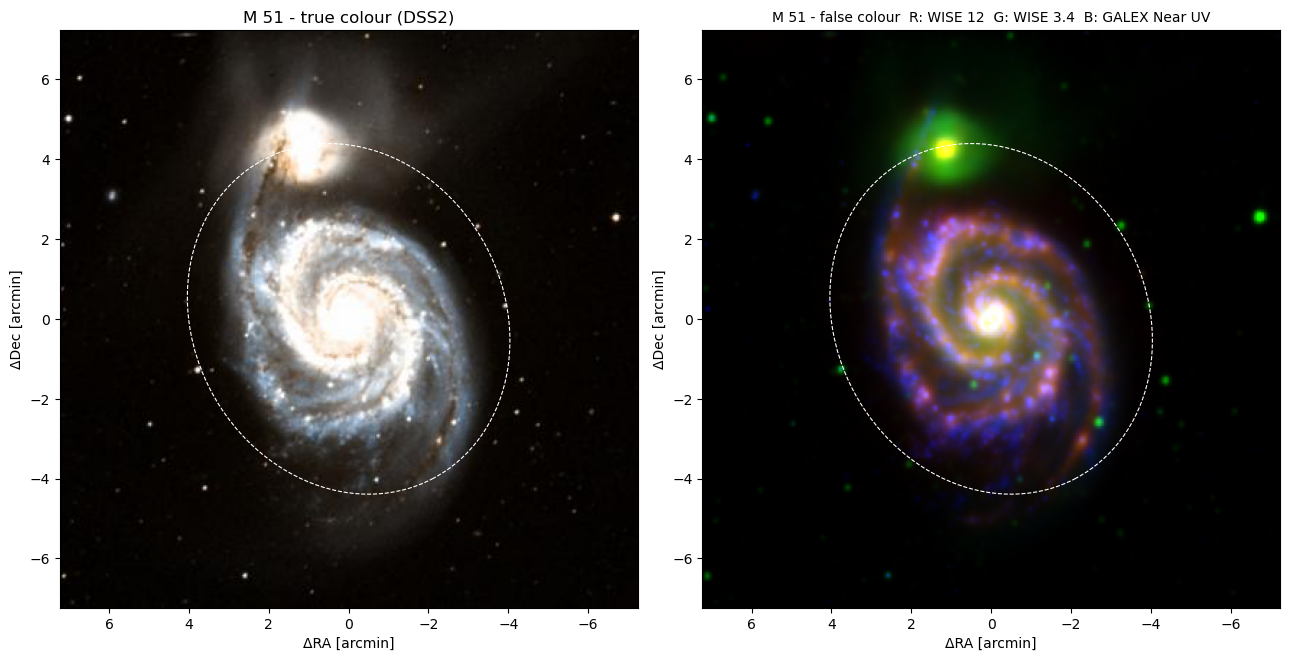

In [5]:
# 4. Colour images: true-colour optical (DSS2 / Pan-STARRS via CDS hips2fits) and false-colour composite
HIPS = "CDS/P/DSS2/color"   # alternatives: "CDS/P/PanSTARRS/DR1/color-z-zg-g" (dec > -30), "CDS/P/SDSS9/color"

optical = hips2fits.query(hips=HIPS, width=PIXELS, height=PIXELS, ra=Angle(info["ra"] * u.deg),
                          dec=Angle(info["dec"] * u.deg), fov=Angle(fov), projection="TAN", format="jpg")

# False colour: red = warm dust (WISE 12), green = old stars (WISE 3.4), blue = young stars (GALEX NUV)
CHANNELS = ["WISE 12", "WISE 3.4", "GALEX Near UV"]
available = [c for c in CHANNELS if c in images]
if len(available) < 3:                      # e.g. no GALEX coverage -> use DSS2 Blue for blue channel
    available = [c for c in ["WISE 12", "WISE 3.4", "DSS2 Blue"] if c in images]
rgb = np.dstack([stretch(images[c], lo=50, hi=99.8) for c in available])   # lo=50: sky -> black

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
axes[0].imshow(optical, extent=extent)      # hips2fits jpg rows run north -> south
axes[0].set_title(f"{SELECTED_GALAXY} - true colour ({HIPS.split('/')[2]})")
axes[1].imshow(rgb, origin="lower", extent=extent)
axes[1].set_title(f"{SELECTED_GALAXY} - false colour  R: {available[0]}  G: {available[1]}  B: {available[2]}", fontsize=10)
for ax in axes:
    ax.add_patch(catalog_ellipse())
    ax.set_xlabel("ΔRA [arcmin]")
    ax.set_ylabel("ΔDec [arcmin]")
fig.tight_layout()
plt.show()

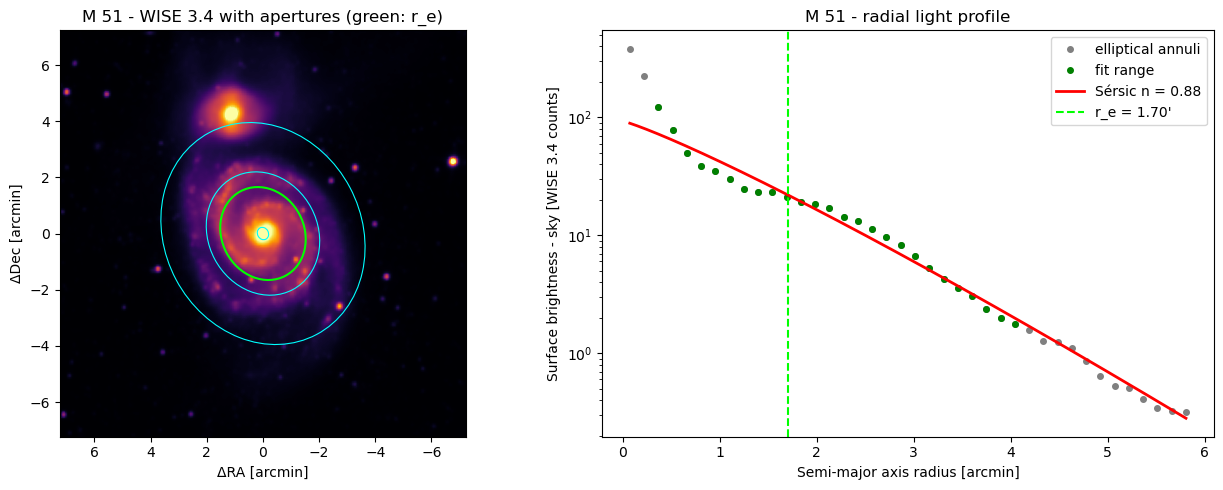

✅ Sérsic fit in WISE 3.4
  Sérsic index:      n = 0.88 ± 0.12   ->  disk-dominated (spiral / S0)
  Hubble type:       SA   <- catalog classification for comparison
  Effective radius:  r_e = 1.70' = 3.89 kpc  (half-light radius)
  Disk scale length: h ≈ 1.02' = 2.32 kpc  (Milky Way: ~2.6 kpc)
  Axis ratio b/a:    0.86  ->  inclination ≈ 31 deg (thin disk)


In [6]:
# 5. Radial surface-brightness profile and Sérsic fit
# Sérsic law I(r) = I_e * exp(-b_n * ((r / r_e)^(1/n) - 1)),  n ~ 1: exponential disk (spiral), n ~ 4: de Vaucouleurs (elliptical)
BAND    = "WISE 3.4"    # near/mid-IR traces stellar mass and is barely affected by dust
N_BINS  = 40
R_FIT   = (0.05, 0.9)   # fit range in units of the catalog semi-major axis (excludes PSF core and sky)

img = images[BAND]
ny, nx = img.shape
yy, xx = np.mgrid[:ny, :nx]
dx = -(xx - (nx - 1) / 2) * pix_arcmin            # arcmin, east positive
dy =  (yy - (ny - 1) / 2) * pix_arcmin            # arcmin, north positive

# Elliptical radius from catalog axis ratio and position angle (PA measured north -> east)
pa = np.deg2rad(pa_deg)
q = b_arcmin / a_arcmin
r_major = dx * np.sin(pa) + dy * np.cos(pa)
r_minor = dx * np.cos(pa) - dy * np.sin(pa)
r_ell = np.hypot(r_major, r_minor / q)            # semi-major-axis equivalent radius [arcmin]

a_cat = a_arcmin / 2
sky = np.nanmedian(img[r_ell > 1.1 * a_cat])       # background outside the galaxy
edges = np.linspace(0, 1.3 * a_cat, N_BINS + 1)
r_mid = 0.5 * (edges[1:] + edges[:-1])
prof = np.array([np.nanmedian(img[(r_ell >= lo) & (r_ell < hi)]) - sky for lo, hi in zip(edges[:-1], edges[1:])])

def sersic(r, I_e, r_e, n):
    b_n = gammaincinv(2 * n, 0.5)                  # r_e encloses half the light
    return I_e * np.exp(-b_n * ((r / r_e) ** (1 / n) - 1))

sel = (r_mid > R_FIT[0] * a_cat) & (r_mid < R_FIT[1] * a_cat) & (prof > 0)
p0 = [np.interp(a_cat / 3, r_mid, prof), a_cat / 3, 2.0]
popt, pcov = curve_fit(lambda r, lnI, r_e, n: np.log(sersic(r, np.exp(lnI), r_e, n)),
                       r_mid[sel], np.log(prof[sel]), p0=[np.log(max(p0[0], 1e-6)), p0[1], p0[2]],
                       bounds=([-np.inf, 0.01, 0.3], [np.inf, 5 * a_cat, 10]))
I_e, r_e, n = np.exp(popt[0]), popt[1], popt[2]
n_err = np.sqrt(pcov[2, 2])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(stretch(img), origin="lower", cmap="inferno", extent=extent)
for f in [R_FIT[0], 0.5, R_FIT[1]]:
    axes[0].add_patch(Ellipse((0, 0), 2 * f * a_cat * q, 2 * f * a_cat, angle=-np.rad2deg(pa),
                              fill=False, ec="cyan", lw=0.8))
axes[0].add_patch(Ellipse((0, 0), 2 * r_e * q, 2 * r_e, angle=-np.rad2deg(pa), fill=False, ec="lime", lw=1.5))
axes[0].set_title(f"{SELECTED_GALAXY} - {BAND} with apertures (green: r_e)")
axes[0].set_xlabel("ΔRA [arcmin]")
axes[0].set_ylabel("ΔDec [arcmin]")

axes[1].semilogy(r_mid, np.where(prof > 0, prof, np.nan), "o", c="grey", ms=4, label="elliptical annuli")
axes[1].semilogy(r_mid[sel], prof[sel], "o", c="green", ms=4, label="fit range")
r_plot = np.linspace(r_mid[0], r_mid[-1], 300)
axes[1].semilogy(r_plot, sersic(r_plot, I_e, r_e, n), c="red", lw=2, label=f"Sérsic n = {n:.2f}")
axes[1].axvline(r_e, color="lime", ls="--", label=f"r_e = {r_e:.2f}'")
axes[1].set_xlabel("Semi-major axis radius [arcmin]")
axes[1].set_ylabel(f"Surface brightness - sky [{BAND} counts]")
axes[1].set_title(f"{SELECTED_GALAXY} - radial light profile")
axes[1].legend()
fig.tight_layout()
plt.show()

# Print results
kind = ("disk-dominated (spiral / S0)" if n < 2 else
        "intermediate (bulge + disk)" if n < 2.5 else "spheroid-dominated (elliptical / classical bulge)")
print(f"✅ Sérsic fit in {BAND}")
print(f"  Sérsic index:      n = {n:.2f} ± {n_err:.2f}   ->  {kind}")
print(f"  Hubble type:       {info['morph_type']}   <- catalog classification for comparison")
print(f"  Effective radius:  r_e = {r_e:.2f}' = {r_e * kpc_per_arcmin:.2f} kpc  (half-light radius)")
if n < 2:
    h = r_e / gammaincinv(2, 0.5)                   # for n = 1: r_e = 1.678 h
    print(f"  Disk scale length: h ≈ {h:.2f}' = {h * kpc_per_arcmin:.2f} kpc  (Milky Way: ~2.6 kpc)")
if n < 2.5:
    print(f"  Axis ratio b/a:    {q:.2f}  ->  inclination ≈ {np.rad2deg(np.arccos(np.clip(q, 0, 1))):.0f} deg (thin disk)")